Build Data Loader

In [ ]:
import pandas as pd
import torch
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
import numpy as np
from tqdm import tqdm

class DeepfakeDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.data = pd.read_csv(csv_path, header=0)
        # Remove any rows where 'label' is not a digit (e.g., header rows)
        self.data = self.data[self.data['label'].astype(str).str.isdigit()]
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx]['filepath']
        label = int(self.data.iloc[idx]['label'])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label)              


In [71]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # [B, 16, 112, 112]
        x = self.pool(F.relu(self.conv2(x)))  # [B, 32, 56, 56]
        x = x.view(-1, 32 * 56 * 56)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


Create Transformations

Initialize Datasets

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load and split data
df = pd.read_csv("data/labels.csv", header=0)

# Calculate class distribution
class_counts = df['label'].value_counts()
print("Original class distribution:")
print(class_counts)

# Step 1: Split with stratification
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    stratify=df['label'], 
    random_state=42
)

# Step 2: Balance training data through oversampling
majority_count = train_df['label'].value_counts().max()
train_dfs = []

for label in train_df['label'].unique():
    label_df = train_df[train_df['label'] == label]
    # Oversample minority class
    resampled_df = label_df.sample(
        n=majority_count, 
        replace=True, 
        random_state=42
    )
    train_dfs.append(resampled_df)

balanced_train_df = pd.concat(train_dfs).reset_index(drop=True)
print("\nBalanced class distribution:")
print(balanced_train_df['label'].value_counts())

# Save balanced datasets
balanced_train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)

# Step 3: Enhanced transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])  # ImageNet stats
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

# Step 4: Compute class weights for loss function
labels = balanced_train_df['label'].values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Step 5: Load datasets with separate transforms
train_dataset = DeepfakeDataset('train.csv', transform=train_transform)
val_dataset = DeepfakeDataset('val.csv', transform=val_transform)

# Step 6: Configure dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True,  # Already balanced, so we can use shuffle
    num_workers=4,  # Parallel loading
    pin_memory=True  # Faster data transfer to GPU
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Model setup with improved initialization
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.1, 
    patience=3
)

Original class distribution:
label
1    77627
0    16260
Name: count, dtype: int64

Balanced class distribution:
label
0    62101
1    62101
Name: count, dtype: int64


Define the Training Components

In [76]:
from tqdm import tqdm  # Import tqdm for progress bars


def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0

    # Wrap the DataLoader with tqdm for a progress bar
    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    accuracy = correct / len(train_loader.dataset)
    return epoch_loss, accuracy


def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0

    # Wrap the DataLoader with tqdm for a progress bar
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(val_loader.dataset)
    accuracy = correct / len(val_loader.dataset)
    return epoch_loss, accuracy


# Configure DataLoader
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True,
    num_workers=0,  # Set to 0 first to test
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False,
    num_workers=0,  # Set to 0 first to test
    pin_memory=True
)

# Training loop
num_epochs = 10
best_val_loss = float('inf')

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Print metrics
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print("  Saved new best model!")
    
    # Update learning rate
    scheduler.step(val_loss)

Epoch 1/10


  Train Loss: 0.1494 | Train Acc: 0.9424
  Val   Loss: 0.1073 | Val   Acc: 0.9628
  Saved new best model!
Epoch 2/10


  Train Loss: 0.0702 | Train Acc: 0.9736
  Val   Loss: 0.0852 | Val   Acc: 0.9693
  Saved new best model!
Epoch 3/10


  Train Loss: 0.0551 | Train Acc: 0.9797
  Val   Loss: 0.0669 | Val   Acc: 0.9786
  Saved new best model!
Epoch 4/10


  Train Loss: 0.0507 | Train Acc: 0.9819
  Val   Loss: 0.0471 | Val   Acc: 0.9843
  Saved new best model!
Epoch 5/10


...

  Train Loss: 0.0408 | Train Acc: 0.9855
  Val   Loss: 0.0623 | Val   Acc: 0.9833
Epoch 7/10


  Train Loss: 0.0381 | Train Acc: 0.9864
  Val   Loss: 0.0301 | Val   Acc: 0.9914
  Saved new best model!
Epoch 8/10


  Train Loss: 0.0383 | Train Acc: 0.9870
  Val   Loss: 0.0382 | Val   Acc: 0.9884
Epoch 9/10


  Train Loss: 0.0343 | Train Acc: 0.9880
  Val   Loss: 0.0308 | Val   Acc: 0.9915
Epoch 10/10


  Train Loss: 0.0349 | Train Acc: 0.9881
  Val   Loss: 0.0320 | Val   Acc: 0.9895


In [78]:
import torch

# Make sure SimpleCNN class is defined above this cell!

model = SimpleCNN()
model.load_state_dict(torch.load('best_model.pth', map_location=torch.device('cpu')))
model.eval()

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=100352, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

In [79]:
from PIL import Image
from torchvision import transforms
import torch

# Define the transform used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load an image
img_path = "data/cropped/val/real/real_001_frame1.jpg"  # 👈 Use any image path
image = Image.open(img_path).convert('RGB')
image = transform(image).unsqueeze(0)  # Add batch dimension

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image = image.to(device)
model = model.to(device)

# Run inference
with torch.no_grad():
    outputs = model(image)
    probs = torch.softmax(outputs, dim=1)
    pred = torch.argmax(probs, dim=1).item()

print(f"Predicted Class: {pred} ({'REAL' if pred == 0 else 'FAKE'})")


Predicted Class: 0 (REAL)


In [80]:
from sklearn.metrics import classification_report
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=["REAL", "FAKE"]))


              precision    recall  f1-score   support

        REAL       0.96      0.99      0.98      3252
        FAKE       1.00      0.99      0.99     15526

    accuracy                           0.99     18778
   macro avg       0.98      0.99      0.99     18778
weighted avg       0.99      0.99      0.99     18778



Matplotlib is building the font cache; this may take a moment.


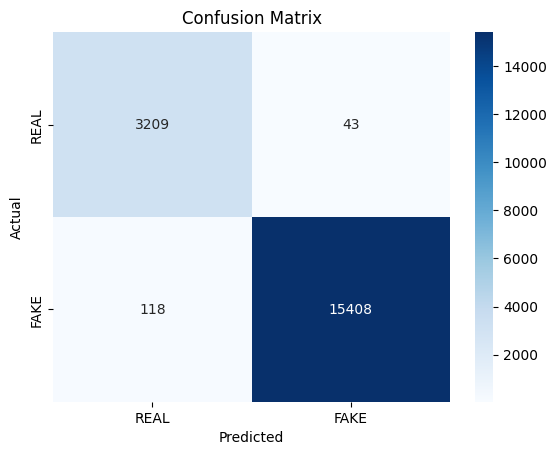

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [84]:
torch.save(model.state_dict(), "revealed_deepfake_detector.pth")

In [3]:
import os, sys, glob, torch
from PIL import Image
from collections import Counter
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

# -------- CONFIG --------
IMAGE_MODEL_WTS = "best_model.pth"   # <- your SimpleCNN weights
REAL_DIR  = "data/cropped/val/real"
FAKE_DIR  = "data/cropped/val/fake"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ------------------------

print("CWD:", os.getcwd())
print("Using REAL dir:", REAL_DIR)
print("Using FAKE dir:", FAKE_DIR)

# === SimpleCNN definition (must match training) ===
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)  # 224->112->56 after two pools
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # [B, 16, 112, 112]
        x = self.pool(F.relu(self.conv2(x)))  # [B, 32, 56, 56]
        x = x.view(-1, 32 * 56 * 56)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# transforms used at train time (match your notebook)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # this MUST match training:
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load model
model = SimpleCNN().to(DEVICE)
state = torch.load(IMAGE_MODEL_WTS, map_location=DEVICE)
model.load_state_dict(state)
model.eval()
print("Loaded weights from:", IMAGE_MODEL_WTS)

# --- CSV-based eval (after model load & transform) ---
import pandas as pd
from torch.utils.data import Dataset, DataLoader

class DeepfakeDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        df = pd.read_csv(csv_path)
        self.paths = df['filepath'].tolist()
        self.labels = df['label'].astype(int).tolist()
        self.transform = transform
    def __len__(self): 
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')
        x = self.transform(img) if self.transform else img
        return x, self.labels[i]

val_ds = DeepfakeDataset("val.csv", transform=transform)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(y.cpu().tolist())   # <-- important fix

from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix

print("Lens:", len(all_labels), len(all_preds))
print("y_true dist:", Counter(all_labels))
print("y_pred dist:", Counter(all_preds))
assert len(all_labels) > 0 and len(all_labels) == len(all_preds), "No eval data or mismatch."

cm = confusion_matrix(all_labels, all_preds, labels=[0,1])
print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)
print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=["REAL","FAKE"]))


CWD: /Users/apple/Desktop/revealed
Using REAL dir: data/cropped/val/real
Using FAKE dir: data/cropped/val/fake
Loaded weights from: best_model.pth
Lens: 18778 18778
y_true dist: Counter({1: 15526, 0: 3252})
y_pred dist: Counter({1: 15451, 0: 3327})

Confusion matrix (rows=true, cols=pred):
[[ 3209    43]
 [  118 15408]]

Classification report:
              precision    recall  f1-score   support

        REAL       0.96      0.99      0.98      3252
        FAKE       1.00      0.99      0.99     15526

    accuracy                           0.99     18778
   macro avg       0.98      0.99      0.99     18778
weighted avg       0.99      0.99      0.99     18778



In [7]:
import os, sys, glob, torch
from PIL import Image
from collections import Counter
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

# -------- CONFIG --------
IMAGE_MODEL_WTS = "best_model.pth"   # <- your SimpleCNN weights
REAL_DIR  = "data/cropped/val/real"
FAKE_DIR  = "data/cropped/val/fake"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ------------------------

print("CWD:", os.getcwd())
print("Using REAL dir:", REAL_DIR)
print("Using FAKE dir:", FAKE_DIR)

# === SimpleCNN definition (must match training) ===
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)  # 224->112->56 after two pools
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # [B, 16, 112, 112]
        x = self.pool(F.relu(self.conv2(x)))  # [B, 32, 56, 56]
        x = x.view(-1, 32 * 56 * 56)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# transforms used at train time (match your notebook)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # this MUST match training:
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load model
model = SimpleCNN().to(DEVICE)
state = torch.load(IMAGE_MODEL_WTS, map_location=DEVICE)
model.load_state_dict(state)
model.eval()
print("Loaded weights from:", IMAGE_MODEL_WTS)

import os, re, pandas as pd, numpy as np, torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --- Dataset that also returns the original filepath ---
class DeepfakeDatasetPaths(Dataset):
    def __init__(self, csv_path, transform=None):
        df = pd.read_csv(csv_path)
        self.paths = df['filepath'].tolist()
        self.labels = df['label'].astype(int).tolist()
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        path = self.paths[i]
        img = Image.open(path).convert('RGB')
        x = self.transform(img) if self.transform else img
        return x, self.labels[i], path

# --- Load val set with paths ---
val_ds = DeepfakeDatasetPaths("val.csv", transform=transform)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False,
                        num_workers=0, pin_memory=torch.cuda.is_available())

# --- Inference: collect per-frame logits/probs ---
from tqdm import tqdm
model.eval()
frame_rows = []
with torch.inference_mode():
    for x, y, paths in tqdm(val_loader, desc="Infer (frames)", total=len(val_loader)):
        x = x.to(DEVICE, non_blocking=True)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # P(fake)
        preds = (probs >= 0.5).astype(int)
        y = np.array(y)

        for pth, label, prob_fake, pred in zip(paths, y, probs, preds):
            frame_rows.append({
                "filepath": pth,
                "label": int(label),
                "prob_fake": float(prob_fake),
                "pred_frame": int(pred)
            })

frames_df = pd.DataFrame(frame_rows)
frames_df.to_csv("val_frame_scores.csv", index=False)
print("Saved per-frame scores to val_frame_scores.csv")

# --- Per-frame metrics ---
cm_frame = confusion_matrix(frames_df["label"], frames_df["pred_frame"], labels=[0,1])
print("\nPer-FRAME confusion matrix (rows=true, cols=pred):\n", cm_frame)
print("\nPer-FRAME report:")
print(classification_report(frames_df["label"], frames_df["pred_frame"], target_names=["REAL","FAKE"]))
try:
    auc_frame = roc_auc_score(frames_df["label"], frames_df["prob_fake"])
    print(f"Per-FRAME ROC-AUC: {auc_frame:.4f}")
except ValueError:
    print("Per-FRAME ROC-AUC: not defined (single-class in labels?)")

# --- Derive a video_id from filename ---
# Expects names like ".../real_001_frame17.jpg" or ".../fake_abc_frame0003.png"
def to_video_id(path):
    name = os.path.basename(path)
    # strip trailing _frame###.ext
    name = re.sub(r'_frame\d+\.(jpg|jpeg|png)$', '', name, flags=re.IGNORECASE)
    return name

frames_df["video_id"] = frames_df["filepath"].apply(to_video_id)

# --- Per-video aggregation (mean prob across frames) ---
video_df = (
    frames_df
    .groupby(["video_id"], as_index=False)
    .agg(
        prob_fake_mean=("prob_fake", "mean"),
        label=("label", "first")  # all frames of a video should share the same label
    )
)
video_df["pred_video"] = (video_df["prob_fake_mean"] >= 0.5).astype(int)

# --- Per-video metrics ---
cm_video = confusion_matrix(video_df["label"], video_df["pred_video"], labels=[0,1])
print("\nPer-VIDEO confusion matrix (rows=true, cols=pred):\n", cm_video)
print("\nPer-VIDEO report:")
print(classification_report(video_df["label"], video_df["pred_video"], target_names=["REAL","FAKE"]))
try:
    auc_video = roc_auc_score(video_df["label"], video_df["prob_fake_mean"])
    print(f"Per-VIDEO ROC-AUC: {auc_video:.4f}")
except ValueError:
    print("Per-VIDEO ROC-AUC: not defined (single-class in labels?)")

video_df.to_csv("val_video_scores.csv", index=False)
print("Saved per-video scores to val_video_scores.csv")


CWD: /Users/apple/Desktop/revealed
Using REAL dir: data/cropped/val/real
Using FAKE dir: data/cropped/val/fake
Loaded weights from: best_model.pth


Infer (frames): 100%|██████████| 147/147 [05:53<00:00,  2.40s/it]


Saved per-frame scores to val_frame_scores.csv

Per-FRAME confusion matrix (rows=true, cols=pred):
 [[ 3209    43]
 [  118 15408]]

Per-FRAME report:
              precision    recall  f1-score   support

        REAL       0.96      0.99      0.98      3252
        FAKE       1.00      0.99      0.99     15526

    accuracy                           0.99     18778
   macro avg       0.98      0.99      0.99     18778
weighted avg       0.99      0.99      0.99     18778

Per-FRAME ROC-AUC: 0.9991

Per-VIDEO confusion matrix (rows=true, cols=pred):
 [[ 943    3]
 [   3 2940]]

Per-VIDEO report:
              precision    recall  f1-score   support

        REAL       1.00      1.00      1.00       946
        FAKE       1.00      1.00      1.00      2943

    accuracy                           1.00      3889
   macro avg       1.00      1.00      1.00      3889
weighted avg       1.00      1.00      1.00      3889

Per-VIDEO ROC-AUC: 1.0000
Saved per-video scores to val_video_scores.cs

In [8]:
import re, pandas as pd

def to_vid(p):
    name = p.split('/')[-1]
    return re.sub(r'_frame\d+\.(jpg|jpeg|png)$','', name, flags=re.I)

tr = pd.read_csv('train.csv')
vl = pd.read_csv('val.csv')

train_vids = set(tr['filepath'].apply(to_vid))
val_vids   = set(vl['filepath'].apply(to_vid))

overlap = train_vids & val_vids
print("Video overlap between train/val:", len(overlap))
print(list(sorted(overlap))[:20])

Video overlap between train/val: 3880
['fake_01_02__hugging_happy__YVGY8LOK', 'fake_01_02__meeting_serious__YVGY8LOK', 'fake_01_02__outside_talking_still_laughing__YVGY8LOK', 'fake_01_02__secret_conversation__YVGY8LOK', 'fake_01_02__talking_against_wall__YVGY8LOK', 'fake_01_02__talking_angry_couch__YVGY8LOK', 'fake_01_02__walk_down_hall_angry__YVGY8LOK', 'fake_01_02__walking_and_outside_surprised__YVGY8LOK', 'fake_01_02__walking_down_indoor_hall_disgust__YVGY8LOK', 'fake_01_02__walking_outside_cafe_disgusted__YVGY8LOK', 'fake_01_03__hugging_happy__ISF9SP4G', 'fake_01_03__kitchen_pan__JZUXXFRB', 'fake_01_03__kitchen_still__JZUXXFRB', 'fake_01_03__meeting_serious__JZUXXFRB', 'fake_01_03__outside_talking_pan_laughing__ISF9SP4G', 'fake_01_03__outside_talking_still_laughing__JZUXXFRB', 'fake_01_03__podium_speech_happy__480LQD1C', 'fake_01_03__podium_speech_happy__JZUXXFRB', 'fake_01_03__secret_conversation__480LQD1C', 'fake_01_03__talking_against_wall__JZUXXFRB']


In [9]:
v = pd.read_csv('val_frame_scores.csv')
chk = v.groupby('filepath'.replace('filepath','video_id',1) if 'video_id' in v.columns else 'filepath')  # fallback
# better: use your function
import re, os
def to_video_id(path):
    name = os.path.basename(path)
    return re.sub(r'_frame\d+\.(jpg|jpeg|png)$','', name, flags=re.I)
v['video_id'] = v['filepath'].apply(to_video_id)

mix = v.groupby('video_id')['label'].nunique().value_counts()
print("Unique labels per video_id:", mix)
bad = v.groupby('video_id')['label'].nunique()
bad = bad[bad>1]
print("Any mixed-label videos?", len(bad))

Unique labels per video_id: label
1    3889
Name: count, dtype: int64
Any mixed-label videos? 0


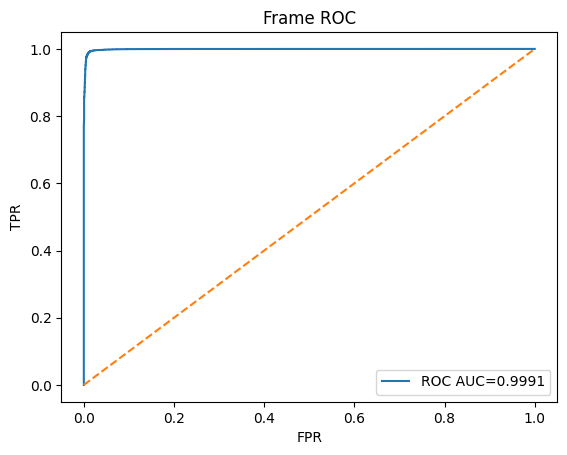

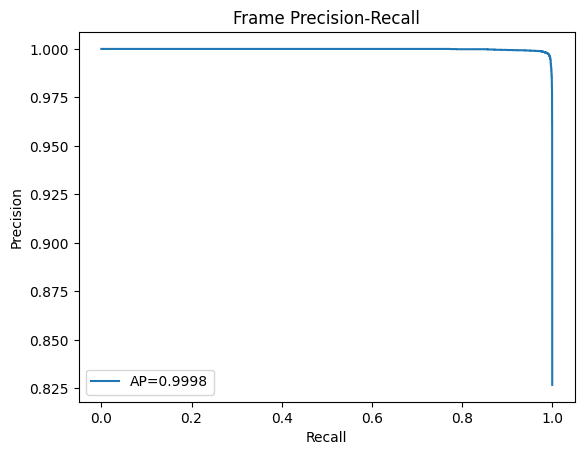

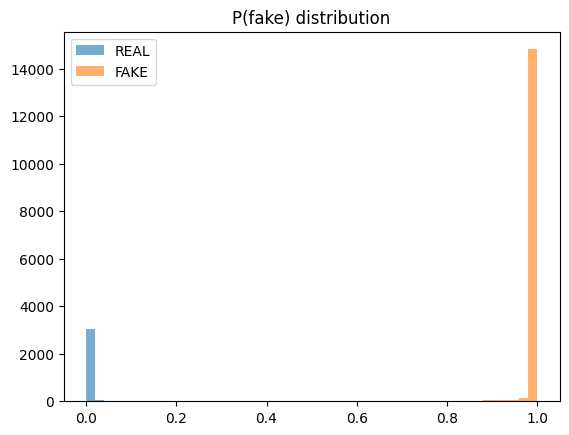

In [10]:
import pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

df = pd.read_csv('val_frame_scores.csv')
y = df['label'].values
p = df['prob_fake'].values

# ROC
fpr, tpr, thr = roc_curve(y, p)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC AUC={roc_auc:.4f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Frame ROC'); plt.legend(); plt.show()

# PR
prec, rec, thr_pr = precision_recall_curve(y, p)
ap = average_precision_score(y, p)
plt.figure()
plt.plot(rec, prec, label=f'AP={ap:.4f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Frame Precision-Recall'); plt.legend(); plt.show()

# Score histograms
import numpy as np
plt.figure()
plt.hist(p[y==0], bins=50, alpha=0.6, label='REAL')
plt.hist(p[y==1], bins=50, alpha=0.6, label='FAKE')
plt.legend(); plt.title('P(fake) distribution'); plt.show()

In [11]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

best = (0, 0, 0)  # (F1, thr, acc)
for t in np.linspace(0.05, 0.95, 19):
    pred = (p >= t).astype(int)
    f1 = f1_score(y, pred)
    acc = accuracy_score(y, pred)
    if f1 > best[0]:
        best = (f1, t, acc)
print(f"Best F1={best[0]:.4f} at threshold={best[1]:.2f} (acc={best[2]:.4f})")


Best F1=0.9955 at threshold=0.25 (acc=0.9925)


In [12]:
import os, shutil
mist_dir = 'analysis_errors'
for sub in ['fp', 'fn']: os.makedirs(os.path.join(mist_dir, sub), exist_ok=True)

pred = (df['prob_fake'] >= 0.5).astype(int)
errs = df.assign(pred=pred)
FP = errs[(errs['label']==0) & (errs['pred']==1)].head(100)  # trim for convenience
FN = errs[(errs['label']==1) & (errs['pred']==0)].head(100)

for row in FP.itertuples():
    shutil.copy2(row.filepath, os.path.join(mist_dir, 'fp', os.path.basename(row.filepath)))
for row in FN.itertuples():
    shutil.copy2(row.filepath, os.path.join(mist_dir, 'fn', os.path.basename(row.filepath)))

print("Saved examples to analysis_errors/fp and analysis_errors/fn")

Saved examples to analysis_errors/fp and analysis_errors/fn


In [15]:
import torch
from torchvision import transforms
# assumes `model` is loaded as in your eval script

dummy = torch.randn(1,3,224,224)
ts = torch.jit.trace(model.cpu(), dummy)
ts.save("image_simplecnn_ts.pt")
print("Saved TorchScript to image_simplecnn_ts.pt")

import torch.onnx
torch.onnx.export(model.cpu(), dummy, "image_simplecnn.onnx",
                  input_names=['input'], output_names=['logits'],
                  opset_version=12, dynamic_axes={'input':{0:'batch'}, 'logits':{0:'batch'}})
print("Saved ONNX to image_simplecnn.onnx")


Saved TorchScript to image_simplecnn_ts.pt
Saved ONNX to image_simplecnn.onnx


Using conv weights: conv1.weight shape: (16, 3, 3, 3)


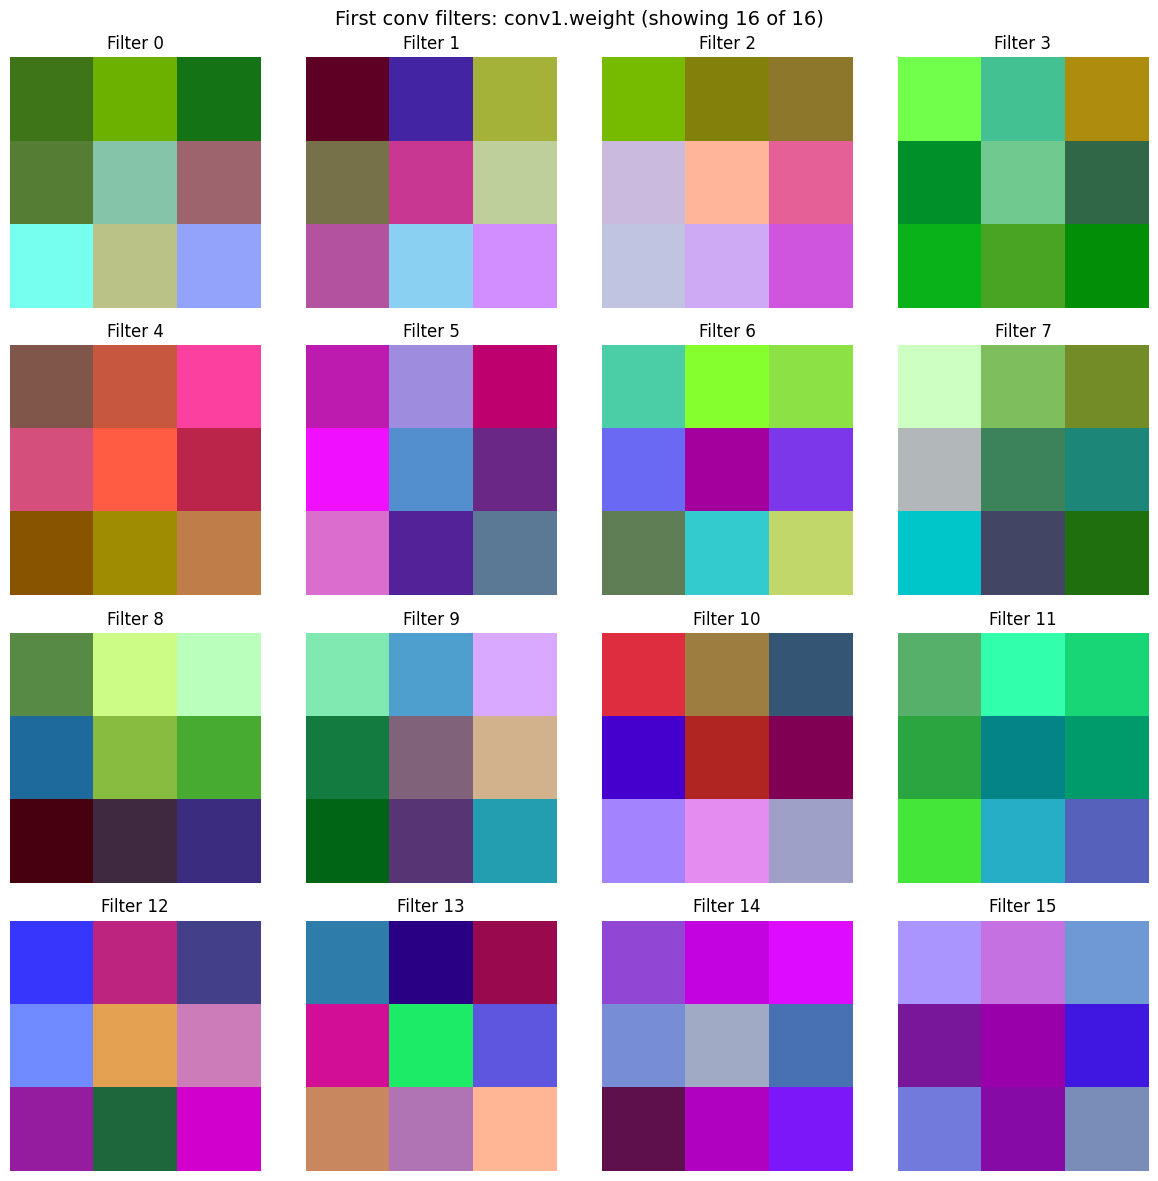

Saved: cnn_firstconv_filters.png


In [18]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from collections import OrderedDict

MODEL_STATE_PATH = "best_model.pth"
MAX_FILTERS = 32       # how many filters to show
OUTPUT_FILE  = "cnn_firstconv_filters.png"

state = torch.load(MODEL_STATE_PATH, map_location="cpu")
if not isinstance(state, OrderedDict):
    raise RuntimeError("Need a state_dict (.pth with weights only) for this cell.")

# Try to find a 4D conv weight tensor: [out_channels, in_channels, kH, kW]
conv_candidates = [(k, v) for k, v in state.items() if isinstance(v, torch.Tensor) and v.ndim == 4]
if not conv_candidates:
    raise RuntimeError("No 4D tensors found. Cannot locate a conv weight in this state_dict.")

# Heuristic: pick the smallest 'first' conv by name or out_channels
conv_candidates.sort(key=lambda kv: (kv[1].shape[0], kv[0]))  # sort by out_channels then name
first_key, W = conv_candidates[0]
print("Using conv weights:", first_key, "shape:", tuple(W.shape))  # e.g., (16, 3, 3, 3)

W = W.detach().cpu()  # [C_out, C_in, kH, kW]
C_out, C_in, kH, kW = W.shape
show = min(C_out, MAX_FILTERS)

# Normalize each filter for display
def norm01(x):
    x = x - x.min()
    x = x / (x.max() + 1e-8)
    return x

cols = int(np.ceil(np.sqrt(show)))
rows = int(np.ceil(show / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
axes = np.atleast_1d(axes).ravel()

for i in range(rows * cols):
    ax = axes[i]
    if i < show:
        ker = W[i]  # [C_in, kH, kW]
        if C_in == 3:
            # Convert to HxWx3 for visualization
            img = ker.permute(1,2,0).numpy()
            img = norm01(img)
            ax.imshow(img)
        else:
            # Show the first input-channel slice as grayscale
            img = ker[0].numpy()
            img = norm01(img)
            ax.imshow(img, cmap="viridis")
        ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.suptitle(f"First conv filters: {first_key} (showing {show} of {C_out})", fontsize=14)
plt.tight_layout()
plt.show()
fig.savefig(OUTPUT_FILE, dpi=300, bbox_inches="tight")
print(f"Saved: {OUTPUT_FILE}")


Saved cnn_firstconv_filters_grayscale.png


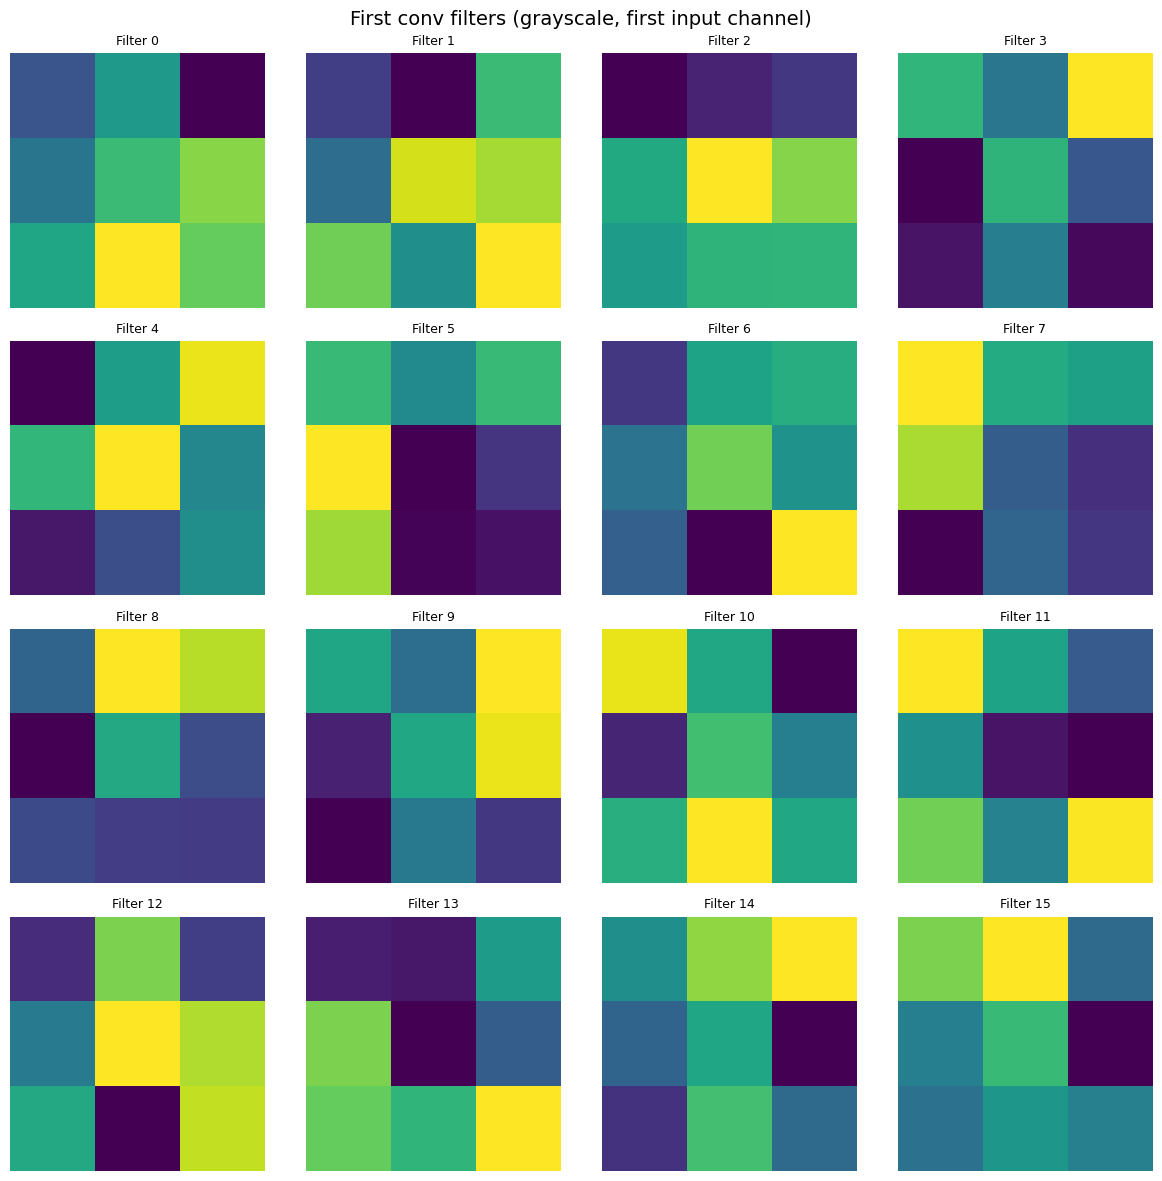

In [19]:
# Plot grayscale version (first input channel of each kernel)
import matplotlib.pyplot as plt
import numpy as np
import torch

W = state[first_key].detach().cpu()  # shape [C_out, C_in, kH, kW]
C_out, C_in, kH, kW = W.shape
show = min(C_out, 32)
cols = int(np.ceil(np.sqrt(show)))
rows = int(np.ceil(show / cols))

def norm01(x):
    x = x - x.min()
    x = x / (x.max() + 1e-8)
    return x

fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
axes = np.atleast_1d(axes).ravel()
for i in range(rows*cols):
    ax = axes[i]
    if i < show:
        ker = W[i, 0]  # first input channel
        ax.imshow(norm01(ker.numpy()), cmap='viridis')
        ax.set_title(f"Filter {i}", fontsize=9)
    ax.axis("off")
plt.suptitle("First conv filters (grayscale, first input channel)", fontsize=14)
plt.tight_layout()
plt.savefig("cnn_firstconv_filters_grayscale.png", dpi=300, bbox_inches="tight")
print("Saved cnn_firstconv_filters_grayscale.png")


Using first conv layer: conv1.weight with shape (16, 3, 3, 3)
Sampled 12 frames


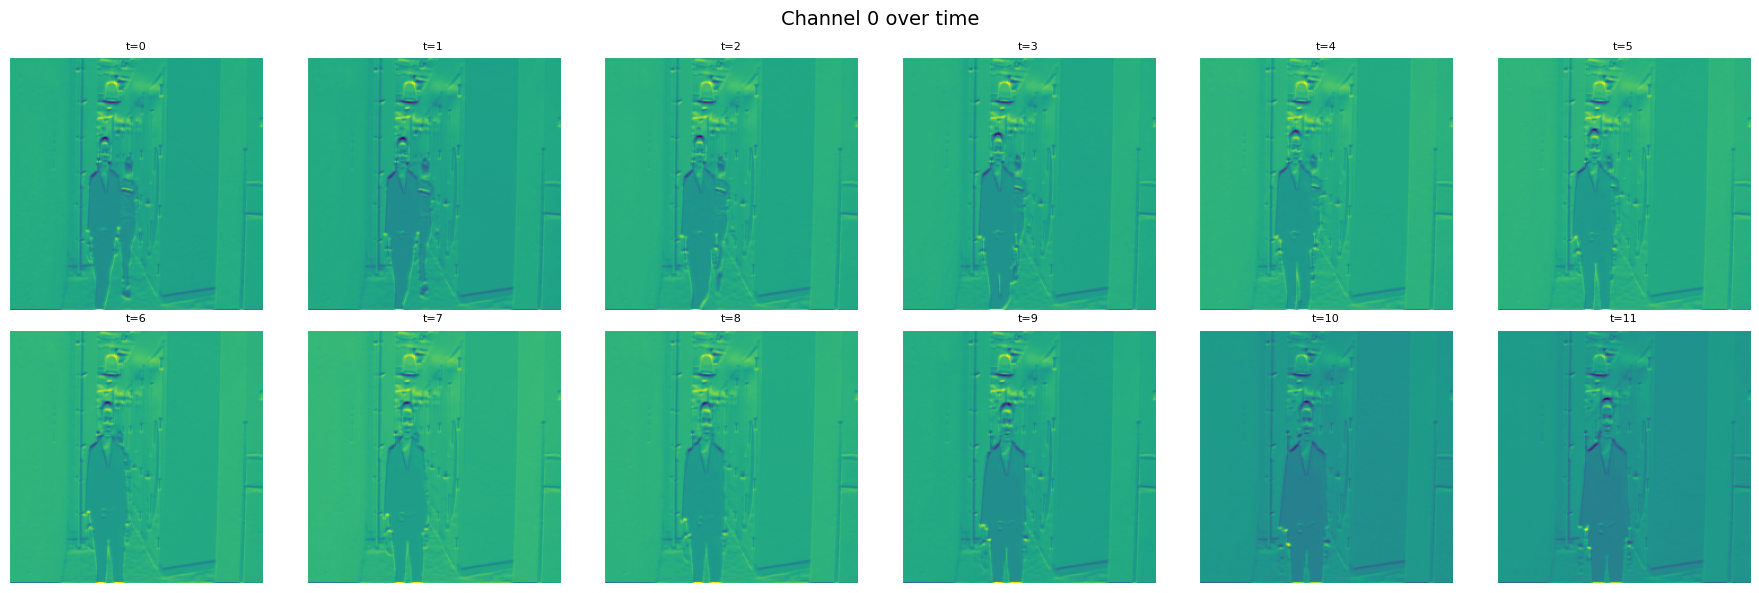

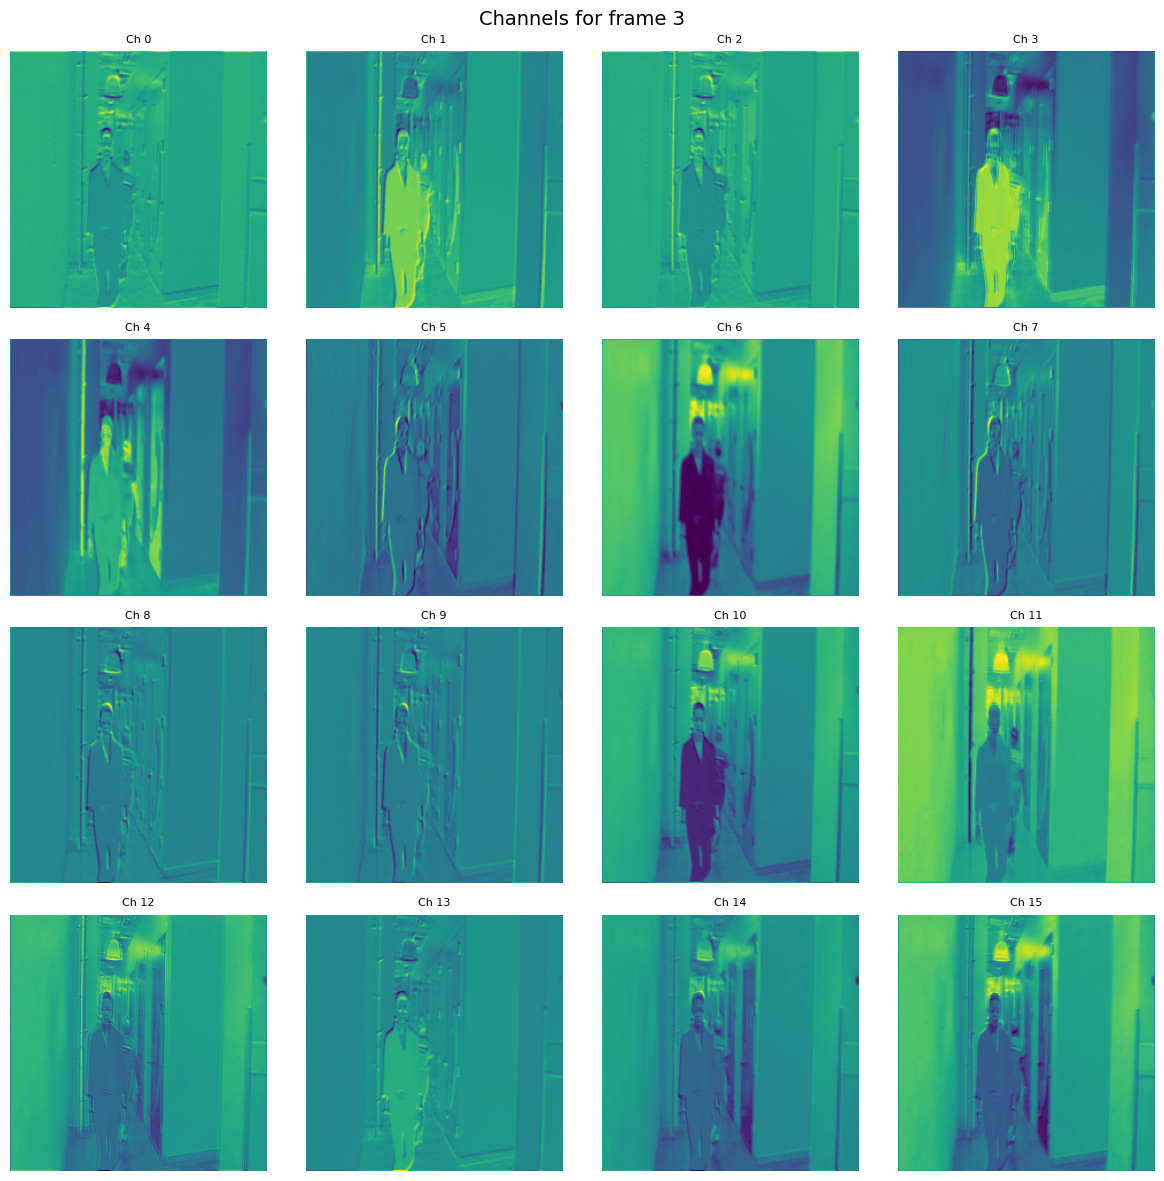

In [27]:
# --- First-layer video activations from your model ---
import torch, torch.nn as nn
from collections import OrderedDict
import numpy as np, matplotlib.pyplot as plt, cv2, math
from PIL import Image
import torchvision.transforms as T

# ===== CONFIG =====
STATE_DICT_PATH = "best_model.pth"   # path to your state_dict
VIDEO_PATH      = "/Users/apple/Desktop/revealed/data/faceforensics/manipulated_sequences/DeepFakeDetection/c23/videos/01_02__exit_phone_room__YVGY8LOK.mp4"   # video file
IMG_SIZE        = 224
MEAN_STD        = ([0.485,0.456,0.406], [0.229,0.224,0.225]) # adjust if trained differently
FRAMES_TO_SAMPLE= 12
FRAME_STRIDE    = 2
TIME_CHANNEL    = 0                  # channel index to visualize over time
MAX_GRID_CH     = 16

# ===== LOAD STATE_DICT & EXTRACT FIRST CONV =====
state = torch.load(STATE_DICT_PATH, map_location="cpu")
if not isinstance(state, OrderedDict):
    raise RuntimeError("Expected state_dict format (.pth with weights only)")

conv_keys = [(k,v) for k,v in state.items() if isinstance(v, torch.Tensor) and v.ndim==4]
conv_keys.sort(key=lambda kv: (kv[1].shape[0], kv[0]))
first_key, W = conv_keys[0]
print(f"Using first conv layer: {first_key} with shape {tuple(W.shape)}")

bias = state.get(first_key.replace("weight", "bias"), None)
conv = nn.Conv2d(W.shape[1], W.shape[0], kernel_size=W.shape[2:], padding=(W.shape[2]//2, W.shape[3]//2), bias=bias is not None)
with torch.no_grad():
    conv.weight.copy_(W)
    if bias is not None:
        conv.bias.copy_(bias)
conv.eval().to("cuda" if torch.cuda.is_available() else "cpu")

# ===== FRAME SAMPLING =====
def sample_frames(video_path, n=FRAMES_TO_SAMPLE, stride=FRAME_STRIDE):
    cap = cv2.VideoCapture(video_path)
    frames = []
    idx = 0
    while cap.isOpened() and len(frames) < n:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % stride == 0:
            frames.append(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
        idx += 1
    cap.release()
    return frames

# ===== PROCESS VIDEO =====
mean, std = MEAN_STD
tfm = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(mean=mean, std=std)])

frames = sample_frames(VIDEO_PATH)
print(f"Sampled {len(frames)} frames")

acts_list = []
device = next(conv.parameters()).device
with torch.no_grad():
    for img in frames:
        x = tfm(img).unsqueeze(0).to(device)
        a = conv(x).cpu().squeeze(0)  # [C,H,W]
        acts_list.append(a)
acts_vid = torch.stack(acts_list)  # [T,C,H,W]
Tlen, C, H, W = acts_vid.shape

# ===== PLOT TIME EVOLUTION =====
cols = min(Tlen, 6)
rows = math.ceil(Tlen / cols)
fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
axes = np.atleast_1d(axes).ravel()
for t in range(rows*cols):
    ax = axes[t]; ax.axis("off")
    if t < Tlen:
        img = acts_vid[t, TIME_CHANNEL].numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img, cmap="viridis")
        ax.set_title(f"t={t}", fontsize=8)
plt.suptitle(f"Channel {TIME_CHANNEL} over time", fontsize=14)
plt.tight_layout()
plt.savefig("vid_activations_time.png", dpi=300, bbox_inches="tight")
plt.show()

# ===== PLOT CHANNEL GRID FOR ONE FRAME =====
frame_idx = min(3, Tlen-1)
show = min(C, MAX_GRID_CH)
cols = math.ceil(math.sqrt(show))
rows = math.ceil(show / cols)
fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
axes = np.atleast_1d(axes).ravel()
for i in range(rows*cols):
    ax = axes[i]; ax.axis("off")
    if i < show:
        img = acts_vid[frame_idx, i].numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img, cmap="viridis")
        ax.set_title(f"Ch {i}", fontsize=8)
plt.suptitle(f"Channels for frame {frame_idx}", fontsize=14)
plt.tight_layout()
plt.savefig("vid_activations_grid.png", dpi=300, bbox_inches="tight")
plt.show()


In [25]:
import os
print(os.path.exists("/Users/apple/Desktop/revealed/data/faceforensics/original_sequences/youtube/c23/videos/932.mp4"))


True


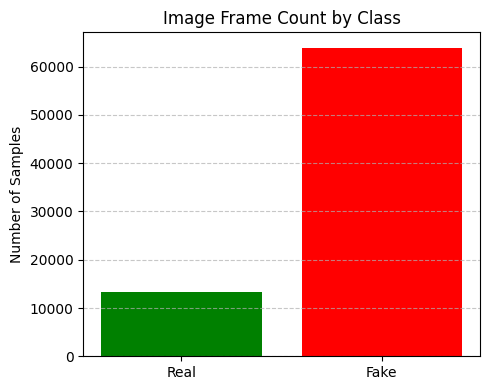

In [28]:
import os
import matplotlib.pyplot as plt

# Paths to your processed image frames
image_real_path = '/Users/apple/Desktop/revealed/data/processed/train/real'
image_fake_path = '/Users/apple/Desktop/revealed/data/processed/train/fake'

# Count images
image_real_count = len(os.listdir(image_real_path))
image_fake_count = len(os.listdir(image_fake_path))

# Plot
plt.figure(figsize=(5, 4))
plt.bar(['Real', 'Fake'], [image_real_count, image_fake_count], color=['green', 'red'])
plt.title("Image Frame Count by Class")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


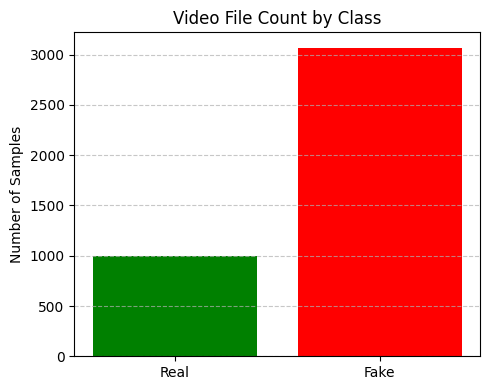

In [29]:
# Paths to video files
video_real_path = '/Users/apple/Desktop/revealed/data/faceforensics/original_sequences/youtube/c23/videos'
video_fake_path = '/Users/apple/Desktop/revealed/data/faceforensics/manipulated_sequences/DeepFakeDetection/c23/videos'

# Count videos
video_real_count = len(os.listdir(video_real_path))
video_fake_count = len(os.listdir(video_fake_path))

# Plot
plt.figure(figsize=(5, 4))
plt.bar(['Real', 'Fake'], [video_real_count, video_fake_count], color=['green', 'red'])
plt.title("Video File Count by Class")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Total samples collected: 20000
Sample values: [50176, 50176, 50176, 50176, 50176, 50176, 50176, 50176, 50176, 50176]


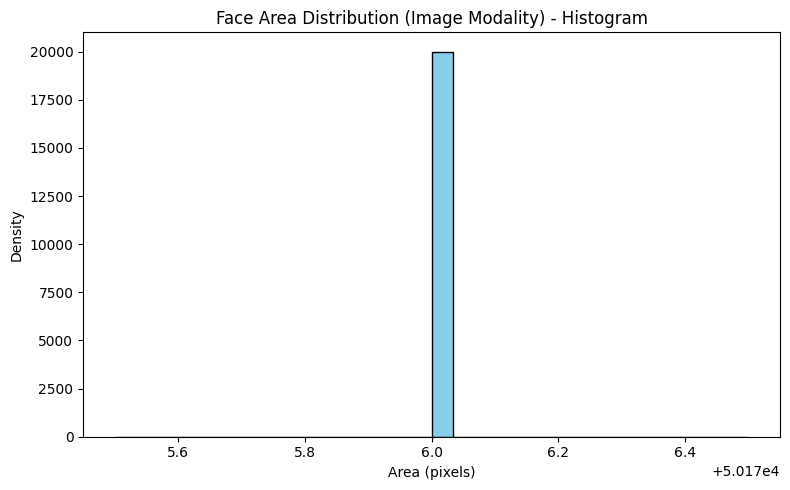

In [32]:
from PIL import Image
import os
import seaborn as sns
import matplotlib.pyplot as plt

def get_face_areas(path):
    areas = []
    valid_ext = ('.jpg', '.jpeg', '.png')
    for cls in ['real', 'fake']:
        cls_dir = os.path.join(path, cls)
        for img_name in os.listdir(cls_dir)[:10000]:  # limit
            if not img_name.lower().endswith(valid_ext):
                continue
            img_path = os.path.join(cls_dir, img_name)
            try:
                img = Image.open(img_path)
                w, h = img.size
                areas.append(w * h)
            except:
                continue
    return areas

areas = get_face_areas('/Users/apple/Desktop/revealed/data/processed/train')

print(f"Total samples collected: {len(areas)}")
print(f"Sample values: {areas[:10]}")

plt.figure(figsize=(8, 5))
if len(areas) < 10 or len(set(areas)) < 3:
    plt.hist(areas, bins=30, color='skyblue', edgecolor='black')
    plt.title("Face Area Distribution (Image Modality) - Histogram")
else:
    sns.kdeplot(areas, fill=True, color='skyblue', linewidth=2)
    plt.title("Face Area Distribution (Image Modality) - KDE")

plt.xlabel("Area (pixels)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


Brightness samples: 2000


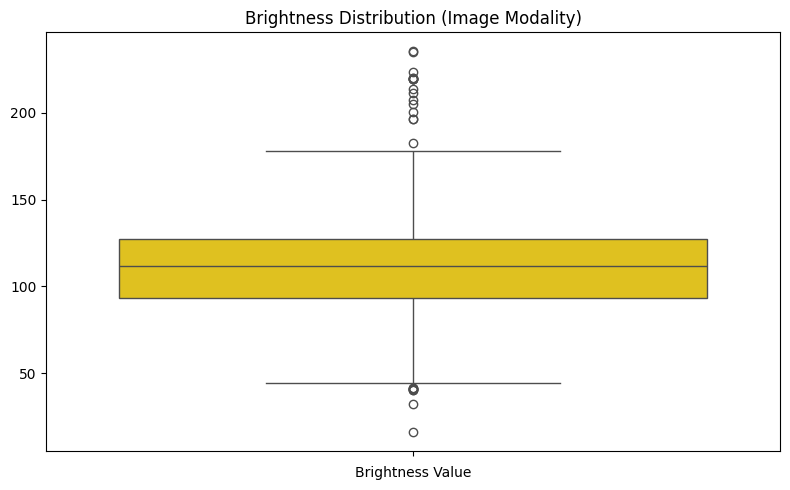

In [33]:
import numpy as np

def get_brightness(path):
    brightness_vals = []
    for cls in ['real', 'fake']:
        cls_dir = os.path.join(path, cls)
        for img_name in os.listdir(cls_dir)[:1000]:
            img_path = os.path.join(cls_dir, img_name)
            try:
                img = Image.open(img_path).convert("L")  # grayscale
                img_arr = np.array(img)
                brightness_vals.append(img_arr.mean())
            except:
                continue
    return brightness_vals

brightness = get_brightness('/Users/apple/Desktop/revealed/data/processed/train')
print(f"Brightness samples: {len(brightness)}")

plt.figure(figsize=(8, 5))
sns.boxplot(data=brightness, color='gold')
plt.title("Brightness Distribution (Image Modality)")
plt.xlabel("Brightness Value")
plt.tight_layout()
plt.show()


Edge density samples: 1000


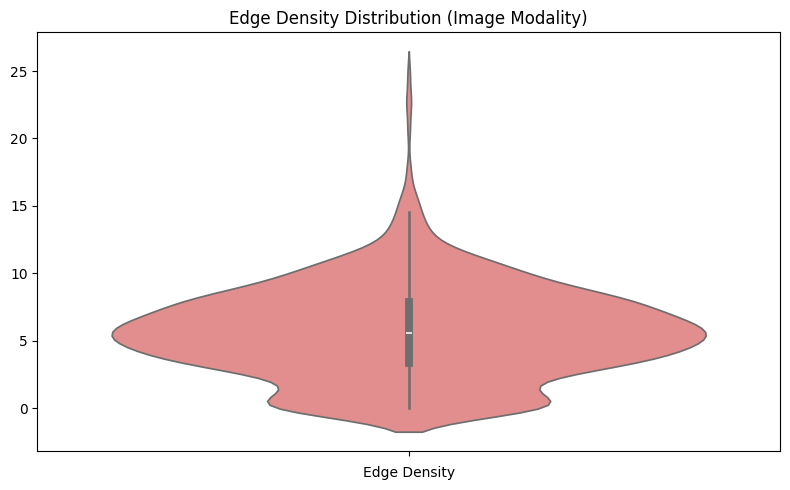

In [34]:
import cv2

def get_edge_density(path):
    densities = []
    for cls in ['real', 'fake']:
        cls_dir = os.path.join(path, cls)
        for img_name in os.listdir(cls_dir)[:500]:
            img_path = os.path.join(cls_dir, img_name)
            try:
                img = Image.open(img_path).convert("L")
                img_arr = np.array(img)
                edges = cv2.Canny(img_arr, 100, 200)
                density = edges.sum() / edges.size
                densities.append(density)
            except:
                continue
    return densities

edges = get_edge_density('/Users/apple/Desktop/revealed/data/processed/train')
print(f"Edge density samples: {len(edges)}")

plt.figure(figsize=(8, 5))
sns.violinplot(data=edges, color='lightcoral')
plt.title("Edge Density Distribution (Image Modality)")
plt.xlabel("Edge Density")
plt.tight_layout()
plt.show()


Total samples: 2000
Sample aspect ratios: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


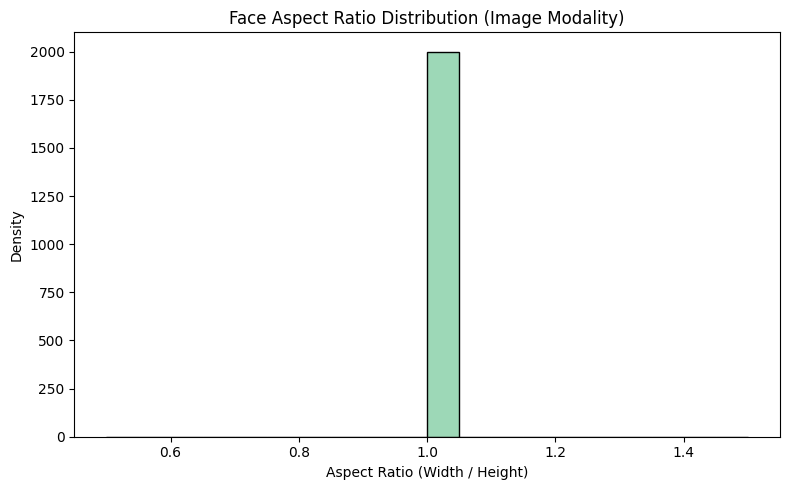

In [35]:
def get_aspect_ratios(path):
    ratios = []
    for cls in ['real', 'fake']:
        cls_dir = os.path.join(path, cls)
        for img_name in os.listdir(cls_dir)[:1000]:
            img_path = os.path.join(cls_dir, img_name)
            try:
                img = Image.open(img_path)
                w, h = img.size
                if h != 0:
                    ratios.append(w / h)
            except:
                continue
    return ratios

ratios = get_aspect_ratios('/Users/apple/Desktop/revealed/data/processed/train')
print(f"Total samples: {len(ratios)}")
print("Sample aspect ratios:", ratios[:10])

plt.figure(figsize=(8, 5))
sns.histplot(ratios, bins=20, kde=True, color='mediumseagreen')
plt.title("Face Aspect Ratio Distribution (Image Modality)")
plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


/var/folders/rw/pr5h099j5s15m07gphdb3zz80000gn/T/ipykernel_4585/1494415710.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=labels, y=frame_counts, palette=["blue", "orange"])


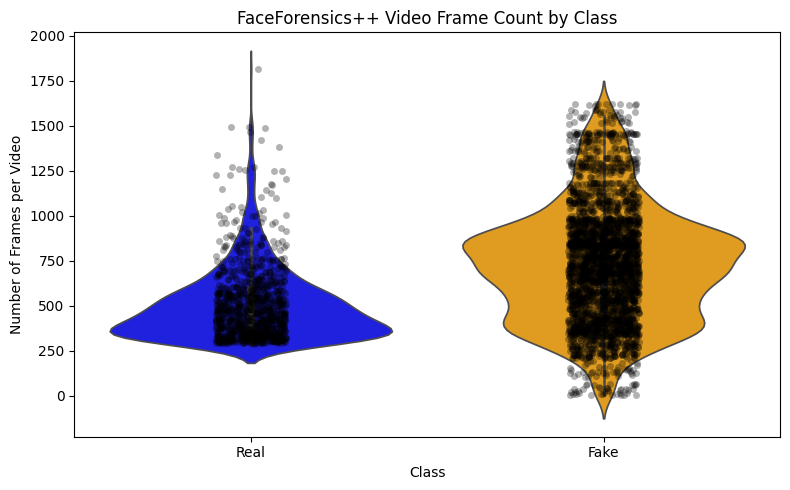

In [36]:
import os
import cv2
import seaborn as sns
import matplotlib.pyplot as plt

def get_frame_counts_ffpp(base_path):
    frame_counts = []
    labels = []

    # Real videos
    real_dir = os.path.join(base_path, 'original_sequences', 'youtube', 'c23', 'videos')
    for fname in os.listdir(real_dir):
        if not fname.endswith('.mp4'):
            continue
        path = os.path.join(real_dir, fname)
        cap = cv2.VideoCapture(path)
        frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_counts.append(frames)
        labels.append('Real')
        cap.release()

    # Fake videos
    fake_dir = os.path.join(base_path, 'manipulated_sequences', 'DeepFakeDetection', 'c23', 'videos')
    for fname in os.listdir(fake_dir):
        if not fname.endswith('.mp4'):
            continue
        path = os.path.join(fake_dir, fname)
        cap = cv2.VideoCapture(path)
        frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_counts.append(frames)
        labels.append('Fake')
        cap.release()

    return frame_counts, labels

# Run the function
frame_counts, labels = get_frame_counts_ffpp('/Users/apple/Desktop/revealed/data/faceforensics')

# Plot as a violin + strip plot combo
plt.figure(figsize=(8, 5))
sns.violinplot(x=labels, y=frame_counts, palette=["blue", "orange"])
sns.stripplot(x=labels, y=frame_counts, color='black', alpha=0.3, jitter=True)
plt.title("FaceForensics++ Video Frame Count by Class")
plt.ylabel("Number of Frames per Video")
plt.xlabel("Class")
plt.tight_layout()
plt.show()


In [39]:
epochs = list(range(1, 11))
train_loss = [0.1494, 0.0702, 0.0551, 0.0507, 0.0452, 0.0408, 0.0381, 0.0383, 0.0343, 0.0349]
val_loss = [0.1073, 0.0852, 0.0669, 0.0471, 0.0340, 0.0623, 0.0301, 0.0382, 0.0308, 0.0320]
train_acc = [0.9424, 0.9736, 0.9797, 0.9819, 0.9839, 0.9855, 0.9864, 0.9870, 0.9880, 0.9881]
val_acc = [0.9628, 0.9693, 0.9786, 0.9843, 0.9885, 0.9833, 0.9914, 0.9884, 0.9915, 0.9895]


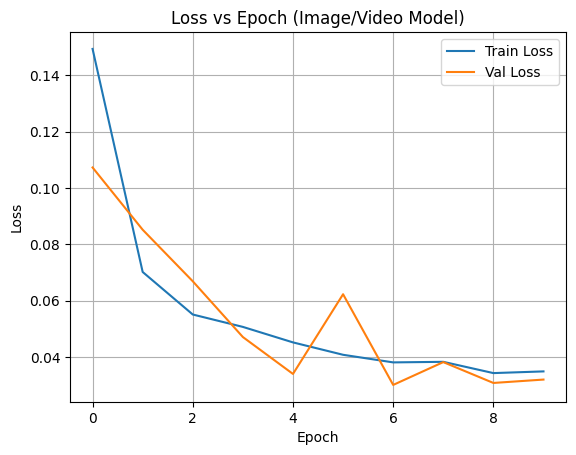

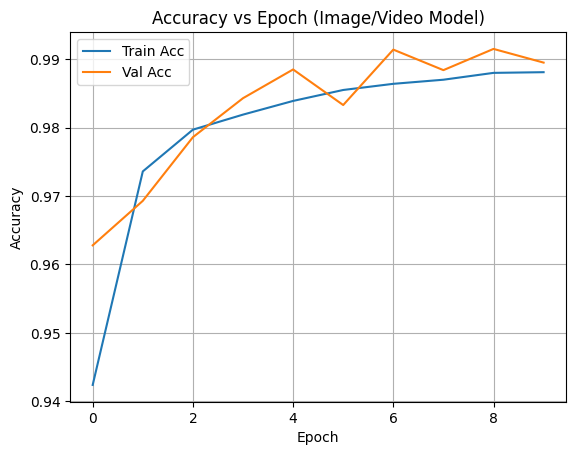

In [40]:
import matplotlib.pyplot as plt

# Loss Plot
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch (Image/Video Model)")
plt.legend()
plt.grid()
plt.savefig("loss_curve_image_video.png", dpi=300)
plt.show()

# Accuracy Plot
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch (Image/Video Model)")
plt.legend()
plt.grid()
plt.savefig("acc_curve_image_video.png", dpi=300)
plt.show()


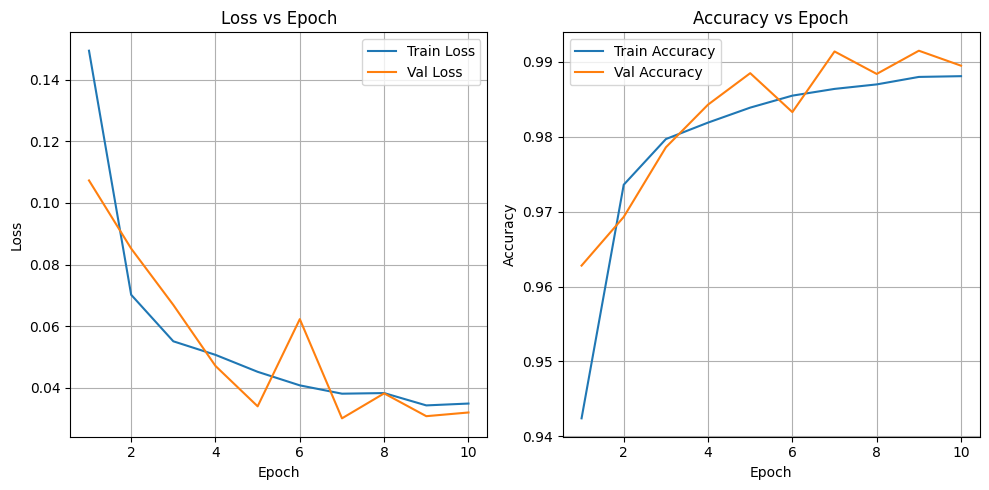

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()


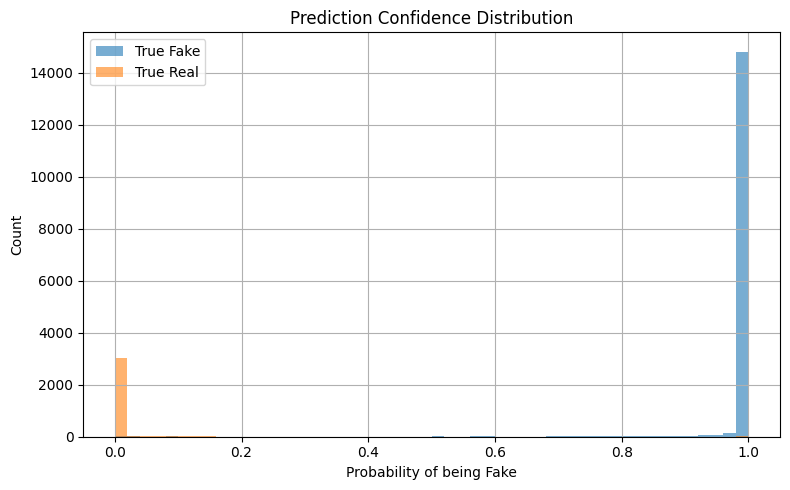

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("val_frame_scores.csv")  # or whichever file has this format

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(df[df['label'] == 1]['prob_fake'], bins=50, alpha=0.6, label='True Fake')
plt.hist(df[df['label'] == 0]['prob_fake'], bins=50, alpha=0.6, label='True Real')
plt.xlabel("Probability of being Fake")
plt.ylabel("Count")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("prediction_distribution.png", dpi=300)
plt.show()

